# 04 — Clusterização de risco

Agrupa genomas por **perfil de resistência adquirida**, não por espécie. As features vêm de
`03_feature_selection` (`data/processed/features_selecionadas.json`), e os splits de
`data/processed/df_estruturada/df_*_risco.csv`.

Fluxo, para os 3 algoritmos (KMeans, Agglomerative, DBSCAN):
1. **Treino**: grid search + CV (Silhouette), com as métricas de fit ao lado (CH, DB).
2. **Escolha do k** com critério explícito: estabilidade no bootstrap, tamanho mínimo de cluster e
   silhouette.
3. **Validação**: hiperparâmetros congelados, aplicados no conjunto de validação escalonado com o
   scaler do TREINO.
4. **Teste**: consistência treino × teste (qui² + ARI, `Clustering.testar_modelo`).

In [37]:
import json
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chisquare
from sklearn.cluster import DBSCAN, AgglomerativeClustering, KMeans
from sklearn.metrics import (adjusted_rand_score, calinski_harabasz_score, davies_bouldin_score,
                             silhouette_score)
from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)


def encontrar_raiz_repo(marcadores=(".git", "data")):
    for pasta in [Path.cwd(), *Path.cwd().parents]:
        if all((pasta / m).exists() for m in marcadores):
            return pasta
    raise FileNotFoundError(f"Nao achei {marcadores} subindo a partir de {Path.cwd()}")


RAIZ = encontrar_raiz_repo()
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

from notebooks.src.clustering import Clustering

RANDOM_STATE = 42
pd.set_option("display.width", 200)

## 1. Dados

In [38]:
pasta = RAIZ / "data/processed/df_estruturada"
df_train = pd.read_csv(pasta / "df_train_risco.csv", index_col=0)
df_valid = pd.read_csv(pasta / "df_valid_risco.csv", index_col=0)
df_test = pd.read_csv(pasta / "df_test_risco.csv", index_col=0)

selecao = json.loads((RAIZ / "data/processed/features_selecionadas.json").read_text())
FEATURES = selecao["features_finais"]

# features que NÃO entram no clustering, só na descrição dos clusters depois
DESCRITIVAS = ["has_mcr", "has_pmqr", "has_ampc_adquirida", "n_classes_adquiridas", "n_genes_adquiridos"]

print(f"treino: {len(df_train)} | validação: {len(df_valid)} | teste: {len(df_test)}")
print("FEATURES:", FEATURES)


def agrupa_especie(s, minimo=14):
    return s.where(s.map(s.value_counts()) >= minimo, "outras")


esp_train = agrupa_especie(df_train["Species"])

treino: 1558 | validação: 445 | teste: 223
FEATURES: ['has_carbapenemase', 'has_mbl', 'has_esbl', 'n_bl_adquiridas', 'has_16s_metilase', 'carbapenemase_plasmidial']


### `StandardScaler` — ajustado SÓ no treino

In [39]:
scaler = StandardScaler().fit(df_train[FEATURES])


def escalona(df):
    return pd.DataFrame(scaler.transform(df[FEATURES]), columns=FEATURES, index=df.index)


Xs_train, Xs_valid, Xs_test = escalona(df_train), escalona(df_valid), escalona(df_test)
X_train, X_valid, X_test = Xs_train.values, Xs_valid.values, Xs_test.values

## 2. Treino — grid search + CV (Silhouette), os 3 algoritmos

Mesmo loop do notebook anterior: top-10 de cada algoritmo por silhouette CV, reajustado no treino
inteiro para calcular as métricas de fit.

In [40]:
def metricas_fit(X, labels):
    mask = labels != -1
    if len(set(labels[mask])) < 2:
        return (np.nan, np.nan, np.nan)
    return (round(silhouette_score(X[mask], labels[mask]), 3),
            round(calinski_harabasz_score(X[mask], labels[mask]), 3),
            round(davies_bouldin_score(X[mask], labels[mask]), 3))


def instanciar(modelo, params):
    params = {k: (int(v) if isinstance(v, float) and float(v).is_integer() and k != "eps" else v)
              for k, v in params.items()}
    if modelo == "kmeans":
        return KMeans(**params, random_state=RANDOM_STATE)
    if modelo == "dbscan":
        return DBSCAN(**params)
    return AgglomerativeClustering(**params)


grid_completo, top10_linhas = {}, []
for modelo in ["kmeans", "agglomerative", "dbscan"]:
    _, _, _, df_grid = Clustering(features=FEATURES, df=df_train, modelo=modelo).cross_validation(print_metricas=False)
    grid_completo[modelo] = df_grid
    top10 = df_grid.nlargest(10, "mean_score")
    param_cols = [c for c in top10.columns if c not in ("mean_score", "std_score")]
    for _, linha in top10.iterrows():
        params = {c: linha[c] for c in param_cols}
        labels = instanciar(modelo, params).fit_predict(X_train)
        ss, chs, dbs = metricas_fit(X_train, labels)
        top10_linhas.append({"modelo": modelo, **params, "mean_score_cv": round(linha["mean_score"], 4),
                             "silhouette_fit": ss, "calinski_harabasz_fit": chs, "davies_bouldin_fit": dbs,
                             "n_clusters_efetivo": len(set(labels) - {-1}),
                             "frac_ruido": round((labels == -1).mean(), 3)})
pd.DataFrame(top10_linhas)

,modelo,n_clusters,init,n_init,mean_score_cv,silhouette_fit,calinski_harabasz_fit,davies_bouldin_fit,n_clusters_efetivo,frac_ruido,metric,linkage,eps,min_samples
0,kmeans,8.0,k-means++,20.0,0.6945,0.699,1.604586e+03,0.611,8,0.000,NaN,NaN,NaN,NaN
1,kmeans,8.0,k-means++,10.0,0.6927,0.699,1.604586e+03,0.611,8,0.000,NaN,NaN,NaN,NaN
2,kmeans,8.0,random,20.0,0.6668,0.664,1.380560e+03,0.766,8,0.000,NaN,NaN,NaN,NaN
3,kmeans,8.0,random,10.0,0.6575,0.664,1.380560e+03,0.766,8,0.000,NaN,NaN,NaN,NaN
4,kmeans,7.0,k-means++,20.0,0.6511,0.638,1.356934e+03,0.636,7,0.000,NaN,NaN,NaN,NaN
5,kmeans,7.0,k-means++,10.0,0.6493,0.638,1.356934e+03,0.636,7,0.000,NaN,NaN,NaN,NaN
6,kmeans,7.0,random,20.0,0.6483,0.641,1.378563e+03,0.624,7,0.000,NaN,NaN,NaN,NaN
7,kmeans,7.0,random,10.0,0.6219,0.659,1.351061e+03,0.659,7,0.000,NaN,NaN,NaN,NaN
8,kmeans,6.0,k-means++,20.0,0.6040,0.602,1.271199e+03,0.751,6,0.000,NaN,NaN,NaN,NaN
9,kmeans,6.0,k-means++,10.0,0.6037,0.602,1.271199e+03,0.751,6,0.000,NaN,NaN,NaN,NaN


## 3. Modelos escolhidos (1 por algoritmo)

O grid da seção 2 não basta para escolher: KMeans e Agglomerative sobem o silhouette até o limite do
grid, e o DBSCAN chega a ≈ 1,0 com dezenas de clusters. Por isso cada algoritmo entra com **uma**
configuração, fixada pelos motivos abaixo. Os números de k = 2 a 12 e o grid proporcional do DBSCAN
vêm da varredura no treino feita na versão anterior deste notebook.

**KMeans: `n_clusters = 6`, `init = "k-means++"`, `n_init = 10`**
- k = 6 é o **menor k** pois:
  - menor cluster ≥ 5% do treino (10,5%);
  - silhouette ≥ 0,50
- k = 5 é instável (ARI = 0,64): a partição muda com pequenas reamostragens.
- k = 7 cria um cluster com menos de 5% dos genomas (4,7%).
- k = 8 também passa, mas só fragmenta perfis que já existem em k = 6. 
- `k-means++` supera `random` em todas as linhas do grid. `n_init = 10` e `n_init = 20` dão o mesmo
  silhouette CV (0,6037 × 0,6040).
- Tem `predict` nativo, então um genoma novo pode ser classificado direto. Por isso é o **modelo
  final**.

**Agglomerative: `n_clusters = 6`, `linkage = "ward"`, `metric = "euclidean"`**
- Usa o **mesmo k** do KMeans, para que as duas partições sejam comparáveis direto pelo ARI
- `ward` é o linkage com melhor silhouette CV em k = 6
- Parte de outra premissa: funde grupos de baixo para cima, sem centróides iniciais aleatórios. Se a
  partição dele bater com a do KMeans, a estrutura não depende da inicialização do KMeans.

**DBSCAN: `eps = 0,75`, `min_samples = 3% do treino` (= 47)**

In [41]:
rng = np.random.default_rng(RANDOM_STATE)   # jitter do PCA

DBSCAN_MS_FRAC = 0.03   # min_samples como fração do n, reescalado na validação/teste (seção 5)

PARAMS_ESCOLHIDOS = {
    "kmeans": {"n_clusters": 6, "init": "k-means++", "n_init": 10},
    "agglomerative": {"n_clusters": 6, "metric": "euclidean", "linkage": "ward"},
    "dbscan": {"eps": 0.75, "min_samples": int(round(DBSCAN_MS_FRAC * len(X_train)))},
}
PARAMS_ESCOLHIDOS

{'kmeans': {'n_clusters': 6, 'init': 'k-means++', 'n_init': 10},
 'agglomerative': {'n_clusters': 6, 'metric': 'euclidean', 'linkage': 'ward'},
 'dbscan': {'eps': 0.75, 'min_samples': 47}}

In [42]:
modelos_treinados, labels_train = {}, {}
for modelo, params in PARAMS_ESCOLHIDOS.items():
    fit = instanciar(modelo, params).fit(X_train)
    modelos_treinados[modelo] = fit
    labels_train[modelo] = fit.labels_
    print(f"{modelo:14s} {pd.Series(fit.labels_).value_counts().sort_index().to_dict()}")

kmeans         {0: 164, 1: 216, 2: 342, 3: 301, 4: 211, 5: 324}
agglomerative  {0: 195, 1: 342, 2: 180, 3: 227, 4: 290, 5: 324}
dbscan         {-1: 134, 0: 207, 1: 134, 2: 213, 3: 290, 4: 324, 5: 99, 6: 92, 7: 65}


### 3.1 Os 3 algoritmos concordam?

In [59]:
labels_train

{'kmeans': array([2, 2, 1, ..., 5, 5, 5], dtype=int32),
 'agglomerative': array([1, 1, 3, ..., 5, 5, 5]),
 'dbscan': array([0, 1, 2, ..., 4, 4, 4])}

In [43]:
nomes = list(labels_train)
concordancia = pd.DataFrame([[adjusted_rand_score(labels_train[a], labels_train[b]) for b in nomes] for a in nomes],
                            index=nomes, columns=nomes)
concordancia["ARI_com_especie"] = [adjusted_rand_score(esp_train, labels_train[m]) for m in nomes]
concordancia.round(3)

,kmeans,agglomerative,dbscan,ARI_com_especie
kmeans,1.000,0.968,0.820,0.205
agglomerative,0.968,1.000,0.826,0.196
dbscan,0.820,0.826,1.000,0.221


<Axes: >

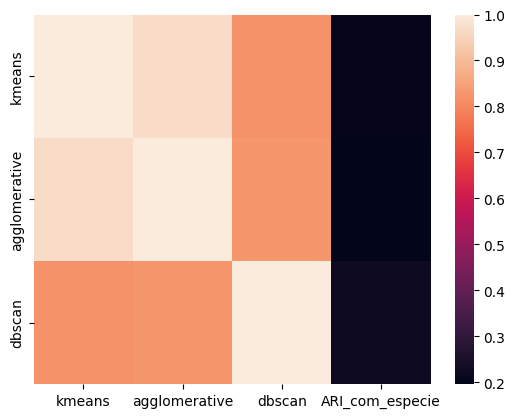

In [44]:
sns.heatmap(concordancia)

## 4. Perfil dos clusters (KMeans, treino)

In [61]:
df_train.groupby(lab_km)[FEATURES + DESCRITIVAS].mean()

,has_carbapenemase,has_mbl,has_esbl,n_bl_adquiridas,has_16s_metilase,carbapenemase_plasmidial,has_mcr,has_pmqr,has_ampc_adquirida,n_classes_adquiridas,n_genes_adquiridos
0,1.000000,1.000000,0.762195,3.804878,0.018293,0.798780,0.042683,0.695122,0.042683,5.579268,12.646341
1,0.013889,0.000000,1.000000,2.189815,0.000000,0.000000,0.046296,0.333333,0.152778,5.004630,8.824074
2,1.000000,0.000000,0.000000,1.672515,0.000000,0.605263,0.011696,0.096491,0.002924,4.073099,6.684211
3,1.000000,0.000000,1.000000,3.561462,0.000000,0.963455,0.009967,0.372093,0.000000,5.302326,10.903654
4,0.919431,0.075829,0.535545,2.312796,1.000000,0.578199,0.000000,0.080569,0.000000,5.909953,13.805687
5,0.000000,0.000000,0.000000,0.453704,0.000000,0.000000,0.046296,0.061728,0.046296,2.033951,2.907407


In [ ]:
lab_km = labels_train["kmeans"]

# média de cada feature pra cada cluster
perfil = df_train.groupby(lab_km)[FEATURES + DESCRITIVAS].mean()
perfil["n"] = pd.Series(lab_km).value_counts().sort_index().values
perfil.T.round(2)

,0,1,2,3,4,5
has_carbapenemase,1.00,0.01,1.00,1.00,0.92,0.00
has_mbl,1.00,0.00,0.00,0.00,0.08,0.00
has_esbl,0.76,1.00,0.00,1.00,0.54,0.00
n_bl_adquiridas,3.80,2.19,1.67,3.56,2.31,0.45
has_16s_metilase,0.02,0.00,0.00,0.00,1.00,0.00
carbapenemase_plasmidial,0.80,0.00,0.61,0.96,0.58,0.00
has_mcr,0.04,0.05,0.01,0.01,0.00,0.05
has_pmqr,0.70,0.33,0.10,0.37,0.08,0.06
has_ampc_adquirida,0.04,0.15,0.00,0.00,0.00,0.05
n_classes_adquiridas,5.58,5.00,4.07,5.30,5.91,2.03


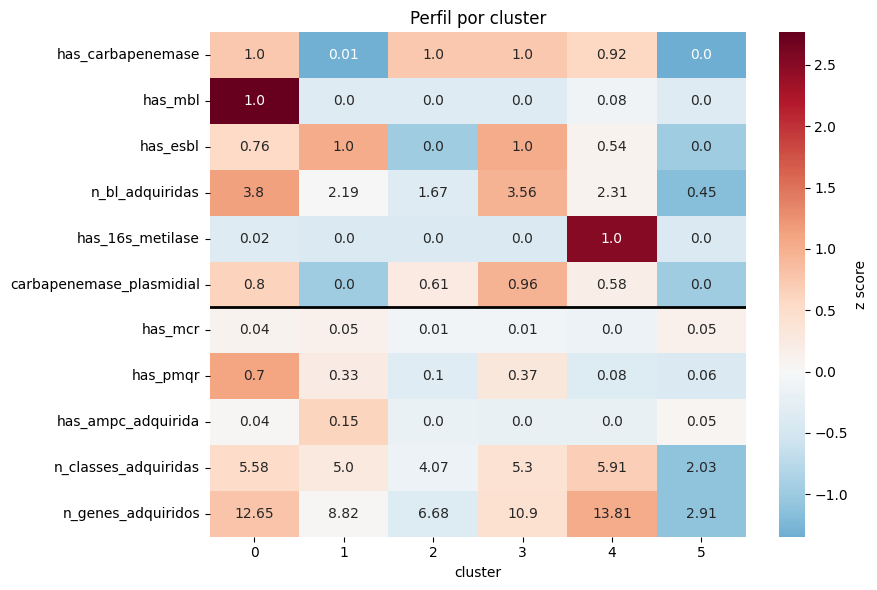

In [65]:
fig, ax = plt.subplots(figsize=(9, 6))

# z score = (média cluster - média treino) / std treino
z = (perfil[FEATURES + DESCRITIVAS] - df_train[FEATURES + DESCRITIVAS].mean()) / df_train[FEATURES + DESCRITIVAS].std()

sns.heatmap(z.T, 
            cmap="RdBu_r", 
            center=0, 
            annot=perfil[FEATURES + DESCRITIVAS].T.round(2), 
            fmt="", 
            ax=ax,
            cbar_kws={"label": "z score"})

ax.axhline(len(FEATURES), c="k", lw=2)
ax.set(title="Perfil por cluster", xlabel="cluster")
plt.tight_layout()
plt.show()

### 4.1 Nome de cada cluster

Nomeação automática a partir do perfil. Um mecanismo entra no nome quando ≥ 70% do cluster o
possui. A fração com carbapenemase em contig plasmidial vai em %, porque a classificação
plasmídeo/cromossomo do geNomad tem ruído em assembly fragmentado.

In [48]:
def nomear(p, limiar=0.7):
    partes = []
    if p["has_carbapenemase"] >= limiar:
        partes.append("MBL" if p["has_mbl"] >= limiar else "carbapenemase serina")
        if p["has_16s_metilase"] >= limiar:
            partes.append("+ metilase 16S")
        if p["has_esbl"] >= limiar:
            partes.append("+ ESBL")
        partes.append(f"(plasm. {p['carbapenemase_plasmidial']:.0%})")
    elif p["has_esbl"] >= limiar:
        partes.append("ESBL sem carbapenemase")
    else:
        partes.append("sem mecanismo principal adquirido")
    return f"C{p.name}: " + " ".join(partes)


NOMES = {c: nomear(perfil.loc[c]) for c in perfil.index}
pd.Series(NOMES, name="perfil").to_frame().join(perfil["n"])

,perfil,n
0,C0: MBL + ESBL (plasm. 80%),164
1,C1: ESBL sem carbapenemase,216
2,C2: carbapenemase serina (plasm. 61%),342
3,C3: carbapenemase serina + ESBL (plasm. 96%),301
4,C4: carbapenemase serina + metilase 16S (plasm. 58%),211
5,C5: sem mecanismo principal adquirido,324


### 4.2 Os clusters atravessam espécies?

Era o objetivo principal. Crosstab espécie × cluster no treino e ARI com a espécie. Para comparação,
as features v1 no mesmo KMeans davam k=2 ≈ *Acinetobacter* × resto.

In [49]:
ct = pd.crosstab(esp_train, pd.Series(lab_km, index=df_train.index).map(NOMES))
print(f"ARI cluster x espécie = {adjusted_rand_score(esp_train, lab_km):.3f}  (0 = independente, 1 = cluster é a espécie)")
ct

ARI cluster x espécie = 0.205  (0 = independente, 1 = cluster é a espécie)


col_0,C0: MBL + ESBL (plasm. 80%),C1: ESBL sem carbapenemase,C2: carbapenemase serina (plasm. 61%),C3: carbapenemase serina + ESBL (plasm. 96%),C4: carbapenemase serina + metilase 16S (plasm. 58%),C5: sem mecanismo principal adquirido
Species,,,,,,
Acinetobacter baumannii,11,1,176,1,90,10
Enterobacter hormaechei,11,1,3,7,3,1
Escherichia coli,11,110,10,2,2,235
Klebsiella aerogenes,2,0,2,5,1,5
Klebsiella pneumoniae,86,91,128,278,114,42
Klebsiella quasipneumoniae,19,1,3,1,0,1
Proteus mirabilis,1,4,1,0,0,8
Serratia marcescens,1,4,15,0,0,5
outras,22,4,4,7,1,17


In [50]:
(ct / ct.sum(axis=0)).round(2).style.background_gradient(cmap="Blues", axis=None).format("{:.0%}")

col_0,C0: MBL + ESBL (plasm. 80%),C1: ESBL sem carbapenemase,C2: carbapenemase serina (plasm. 61%),C3: carbapenemase serina + ESBL (plasm. 96%),C4: carbapenemase serina + metilase 16S (plasm. 58%),C5: sem mecanismo principal adquirido
Species,,,,,,
Acinetobacter baumannii,7%,0%,51%,0%,43%,3%
Enterobacter hormaechei,7%,0%,1%,2%,1%,0%
Escherichia coli,7%,51%,3%,1%,1%,73%
Klebsiella aerogenes,1%,0%,1%,2%,0%,2%
Klebsiella pneumoniae,52%,42%,37%,92%,54%,13%
Klebsiella quasipneumoniae,12%,0%,1%,0%,0%,0%
Proteus mirabilis,1%,2%,0%,0%,0%,2%
Serratia marcescens,1%,2%,4%,0%,0%,2%
outras,13%,2%,1%,2%,0%,5%


### 4.3 Projeção PCA

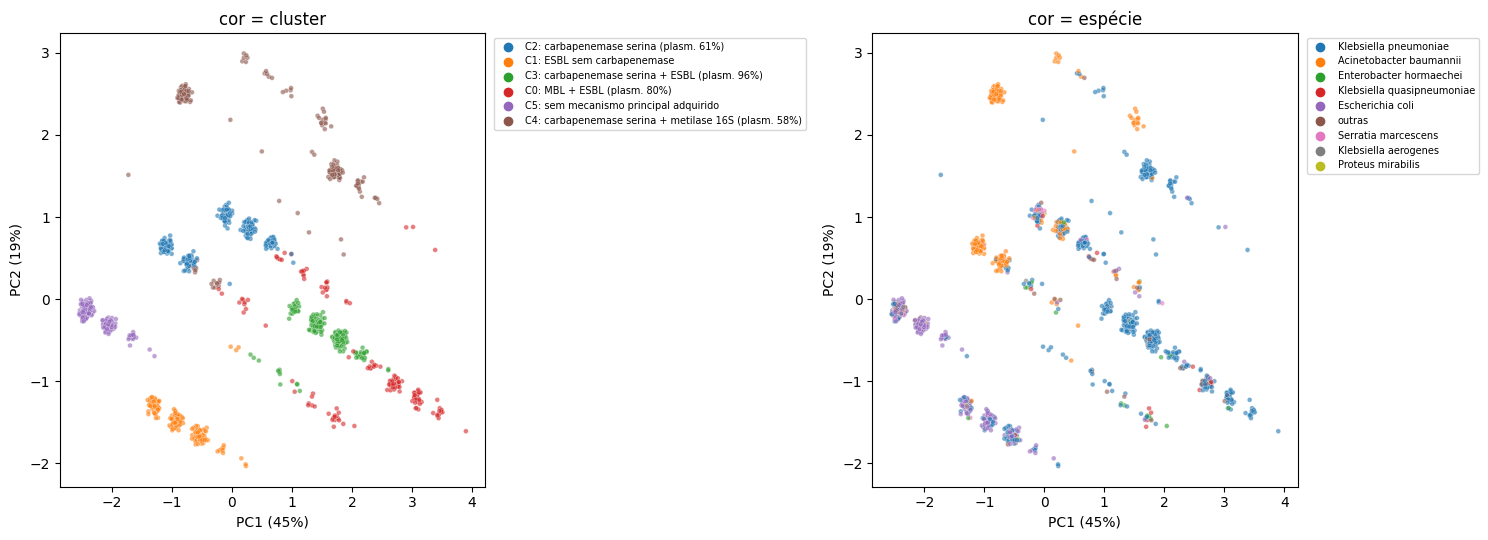

In [51]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE).fit(X_train)
coords = pca.transform(X_train) + rng.normal(0, 0.05, (len(X_train), 2))   # jitter: pontos repetidos
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=pd.Series(lab_km).map(NOMES).values, s=12, alpha=0.6, ax=axes[0])
sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=esp_train.values, s=12, alpha=0.6, ax=axes[1])
for ax, t in zip(axes, ["cor = cluster", "cor = espécie"]):
    ax.set(xlabel=f"PC1 ({pca.explained_variance_ratio_[0]:.0%})", ylabel=f"PC2 ({pca.explained_variance_ratio_[1]:.0%})", title=t)
    ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 5. Validação

1. **Refit**: com os mesmos hiperparâmetros, o conjunto de validação (escalonado com o scaler do
   treino) também tem boa estrutura (silhouette/CH/DB na mesma faixa)?
2. **Projeção × refit**: o modelo do treino, aplicado na validação, dá a mesma partição que um modelo
   novo ajustado direto na validação (ARI)? Projeção: `predict` no KMeans, centróide mais próximo no
   Agglomerative, 1-vizinho no DBSCAN (mesma lógica de `Clustering.testar_modelo`).

In [ ]:
def params_para_n(modelo, params, n):
    if modelo == "dbscan":
        return {**params, "min_samples": max(3, int(round(DBSCAN_MS_FRAC * n)))}
    return params


def projetar(modelo, X_novo):
    fit = modelos_treinados[modelo]
    if modelo == "kmeans":
        return fit.predict(X_novo)
    if modelo == "agglomerative":
        return NearestCentroid().fit(X_train, fit.labels_).predict(X_novo)
    return KNeighborsClassifier(n_neighbors=1).fit(X_train, fit.labels_).predict(X_novo)


def avaliar(X_novo, nome_conjunto):
    linhas = []
    for modelo, params in PARAMS_ESCOLHIDOS.items():
        refit = instanciar(modelo, params_para_n(modelo, params, len(X_novo))).fit_predict(X_novo)
        proj = projetar(modelo, X_novo)
        ss, chs, dbs = metricas_fit(X_novo, refit)
        ss_p, chs_p, dbs_p = metricas_fit(X_novo, proj)
        linhas.append({"modelo": modelo, "conjunto": nome_conjunto,
                       "silhouette_refit": ss, "calinski_harabasz_refit": chs, "davies_bouldin_refit": dbs,
                       "silhouette_projetado": ss_p,
                       "n_clusters_refit": len(set(refit) - {-1}),
                       "ari_projecao_x_refit": round(adjusted_rand_score(proj, refit), 3)})
    return linhas


linhas_treino = []
for modelo in PARAMS_ESCOLHIDOS:
    ss, chs, dbs = metricas_fit(X_train, labels_train[modelo])
    linhas_treino.append({"modelo": modelo, 
                          "conjunto": "treino", 
                          "silhouette_refit": ss,
                          "calinski_harabasz_refit": chs, 
                          "davies_bouldin_refit": dbs,
                          "silhouette_projetado": ss, 
                          "n_clusters_refit": len(set(labels_train[modelo]) - {-1}),
                          "ari_projecao_x_refit": 1.0})

estabilidade = pd.DataFrame(linhas_treino + avaliar(X_valid, "validação")).set_index(["modelo", "conjunto"]).sort_index()
estabilidade

silhouette_refit  calinski_harabasz_refit  davies_bouldin_refit  silhouette_projetado  n_clusters_refit  ari_projecao_x_refit
modelo        conjunto                                                                                                                                
agglomerative treino                0.600                 1254.321                 0.731                 0.600                 6                 1.000
              validação             0.608                  349.368                 0.762                 0.606                 6                 0.981
dbscan        treino                0.792                 4300.926                 0.324                 0.792                 8                 1.000
              validação             0.785                 1104.195                 0.321                 0.782                 8                 0.993
kmeans        treino                0.602                 1271.199                 0.751                 0.602                 6                 1.000
              validação             0.607                  350.099                 0.767                 0.607                 6                 0.995

### 5.1 O perfil dos clusters se repete na validação?

Para o KMeans: perfil médio de cada cluster na validação (rótulo projetado) × treino. Se os
clusters forem reais, as médias devem praticamente coincidir.

In [53]:
lab_valid_km = projetar("kmeans", X_valid)
perfil_valid = df_valid.groupby(lab_valid_km)[FEATURES].mean()
comparacao_perfil = pd.concat({"treino": perfil[FEATURES], "validação": perfil_valid}, axis=1)
comparacao_perfil = comparacao_perfil.swaplevel(axis=1).sort_index(axis=1)
print("maior diferença absoluta treino x validação:",
      (perfil[FEATURES] - perfil_valid).abs().max().round(3).to_dict())
comparacao_perfil.round(2)

maior diferença absoluta treino x validação: {'has_carbapenemase': 0.014, 'has_mbl': 0.019, 'has_esbl': 0.045, 'n_bl_adquiridas': 0.199, 'has_16s_metilase': 0.015, 'carbapenemase_plasmidial': 0.045}


carbapenemase_plasmidial           has_16s_metilase           has_carbapenemase           has_esbl           has_mbl           n_bl_adquiridas          
                    treino validação           treino validação            treino validação   treino validação  treino validação          treino validação
0                     0.80      0.83             0.02      0.03              1.00      1.00     0.76      0.73    1.00      1.00            3.80      3.80
1                     0.00      0.00             0.00      0.00              0.01      0.00     1.00      1.00    0.00      0.00            2.19      2.39
2                     0.61      0.56             0.00      0.00              1.00      1.00     0.00      0.00    0.00      0.00            1.67      1.84
3                     0.96      0.96             0.00      0.00              1.00      1.00     1.00      1.00    0.00      0.00            3.56      3.65
4                     0.58      0.55             1.00      1.00              0.92      0.92     0.54      0.49    0.08      0.06            2.31      2.21
5                     0.00      0.00             0.00      0.01              0.00      0.00     0.00      0.00    0.00      0.00            0.45      0.35

## 6. Teste — consistência treino × teste (qui² + ARI)

`Clustering.testar_modelo` para KMeans e Agglomerative, recebendo os dados **já escalonados** com o
scaler do treino. Os métodos internos dele ajustam sem escalonar, então passar o dado bruto
mistura escalas (a contagem `n_bl_adquiridas` dominaria a distância). Para o DBSCAN, o `testar_modelo`
reutiliza o mesmo `min_samples` no refit do teste (~220 genomas). Por isso o DBSCAN usa a versão
com `min_samples` proporcional (mesma lógica: qui² de proporção + ARI projeção × refit).

In [67]:
{k: v for k, v in PARAMS_ESCOLHIDOS[modelo].items()}

{'n_clusters': 6, 'metric': 'euclidean', 'linkage': 'ward'}

In [54]:
resultados_teste = {}
for modelo in ["kmeans", "agglomerative"]:
    print(f"\n{'#' * 20} {modelo.upper()} {'#' * 20}")
    resultados_teste[modelo] = Clustering(features=FEATURES, df=Xs_train, modelo=modelo).testar_modelo(
        {k: v for k, v in PARAMS_ESCOLHIDOS[modelo].items()}, Xs_test)


#################### KMEANS ####################
 TESTE DE CONSISTÊNCIA TREINO x TESTE (kmeans)
Estatística Qui-Quadrado (χ²): 1.5252
p-valor:                        0.9101
-------------------------------------------------------
Conclusão: Não rejeitamos H0 (p > 0.05).
A distribuição dos clusters no TESTE é CONSISTENTE com o TREINO.
-------------------------------------------------------
Adjusted Rand Index (ARI) treino-projetado x teste-direto: 1.0000
(ARI perto de 1.0 = a partição geométrica é praticamente idêntica)

#################### AGGLOMERATIVE ####################
 TESTE DE CONSISTÊNCIA TREINO x TESTE (agglomerative)
Estatística Qui-Quadrado (χ²): 1.7642
p-valor:                        0.8807
-------------------------------------------------------
Conclusão: Não rejeitamos H0 (p > 0.05).
A distribuição dos clusters no TESTE é CONSISTENTE com o TREINO.
-------------------------------------------------------
Adjusted Rand Index (ARI) treino-projetado x teste-direto: 1.0000
(AR

In [55]:
def testar_dbscan_proporcional(X_novo):
    labels_tr = labels_train["dbscan"]
    proj = projetar("dbscan", X_novo)
    refit = instanciar("dbscan", params_para_n("dbscan", PARAMS_ESCOLHIDOS["dbscan"], len(X_novo))).fit_predict(X_novo)
    todos = np.unique(np.concatenate([labels_tr, proj]))
    esperado = pd.Series(labels_tr).value_counts().reindex(todos, fill_value=0) / len(labels_tr) * len(X_novo)
    observado = pd.Series(proj).value_counts().reindex(todos, fill_value=0)
    chi2, p = chisquare(observado, esperado)
    return chi2, p, adjusted_rand_score(proj, refit)


chi2, p, ari = testar_dbscan_proporcional(X_test)
print(f"DBSCAN — qui² = {chi2:.3f} | p = {p:.4f} | ARI projeção x refit = {ari:.3f}")
resultados_teste["dbscan"] = p > 0.05

DBSCAN — qui² = 4.569 | p = 0.8024 | ARI projeção x refit = 1.000


In [56]:
resumo_teste = pd.DataFrame(avaliar(X_test, "teste")).set_index("modelo")
resumo_teste["distribuicao_consistente_qui2"] = pd.Series(resultados_teste)
resumo_teste

,conjunto,silhouette_refit,calinski_harabasz_refit,davies_bouldin_refit,silhouette_projetado,n_clusters_refit,ari_projecao_x_refit,distribuicao_consistente_qui2
modelo,,,,,,,,
kmeans,teste,0.604,183.401,0.733,0.604,6,1.0,True
agglomerative,teste,0.603,181.820,0.719,0.603,6,1.0,True
dbscan,teste,0.799,711.315,0.314,0.799,8,1.0,True


## 7. Resumo final — os 3 algoritmos

In [57]:
resumo = pd.concat([estabilidade.reset_index(), resumo_teste.reset_index().assign(conjunto="teste")])
resumo = resumo.set_index(["modelo", "conjunto"]).sort_index()[
    ["n_clusters_refit", "silhouette_refit", "davies_bouldin_refit", "calinski_harabasz_refit",
     "ari_projecao_x_refit", "distribuicao_consistente_qui2"]]
resumo

n_clusters_refit  silhouette_refit  davies_bouldin_refit  calinski_harabasz_refit  ari_projecao_x_refit distribuicao_consistente_qui2
modelo        conjunto                                                                                                                                        
agglomerative teste                     6             0.603                 0.719                  181.820                 1.000                          True
              treino                    6             0.600                 0.731                 1254.321                 1.000                           NaN
              validação                 6             0.608                 0.762                  349.368                 0.981                           NaN
dbscan        teste                     8             0.799                 0.314                  711.315                 1.000                          True
              treino                    8             0.792                 0.324                 4300.926                 1.000                           NaN
              validação                 8             0.785                 0.321                 1104.195                 0.993                           NaN
kmeans        teste                     6             0.604                 0.733                  183.401                 1.000                          True
              treino                    6             0.602                 0.751                 1271.199                 1.000                           NaN
              validação                 6             0.607                 0.767                  350.099                 0.995                           NaN

## 8. Rótulos finais

In [68]:
rotulos = pd.concat([
    pd.DataFrame({"cluster": lab_km, "conjunto": "treino"}, index=df_train.index),
    pd.DataFrame({"cluster": lab_valid_km, "conjunto": "validacao"}, index=df_valid.index),
    pd.DataFrame({"cluster": projetar("kmeans", X_test), "conjunto": "teste"}, index=df_test.index),
])

rotulos.head()

,cluster,conjunto
sample,,
GCA_029076165.1,2,treino
GCF_001420335.1,2,treino
GCA_002304205.1,1,treino
GCA_031011085.1,3,treino
GCA_031630615.1,0,treino


In [69]:
rotulos["perfil"] = rotulos["cluster"].map(NOMES)
rotulos = rotulos.join(pd.concat([df_train, df_valid, df_test])[["Species"]])
rotulos.head()

,cluster,conjunto,perfil,Species
sample,,,,
GCA_029076165.1,2,treino,C2: carbapenemase serina (plasm. 61%),Klebsiella pneumoniae
GCF_001420335.1,2,treino,C2: carbapenemase serina (plasm. 61%),Acinetobacter baumannii
GCA_002304205.1,1,treino,C1: ESBL sem carbapenemase,Klebsiella pneumoniae
GCA_031011085.1,3,treino,C3: carbapenemase serina + ESBL (plasm. 96%),Klebsiella pneumoniae
GCA_031630615.1,0,treino,C0: MBL + ESBL (plasm. 80%),Enterobacter hormaechei


In [70]:
rotulos.to_csv(RAIZ / "data/processed/clusters_risco.csv")
rotulos.groupby(["conjunto", "perfil"]).size().unstack(0)

conjunto,teste,treino,validacao
perfil,,,
C0: MBL + ESBL (plasm. 80%),25,164,30
C1: ESBL sem carbapenemase,27,216,72
C2: carbapenemase serina (plasm. 61%),49,342,100
C3: carbapenemase serina + ESBL (plasm. 96%),39,301,98
C4: carbapenemase serina + metilase 16S (plasm. 58%),33,211,53
C5: sem mecanismo principal adquirido,50,324,92
